# Altimetry time series for Narrabeen

## Paths and settings

In [1]:
# paths jupyter utwente
path_input_general = '/home/jovyan/data/98_paper2_kf_dtm/0_input_general/'
path_input = '/home/jovyan/data/98_paper2_kf_dtm/31_Narra_altimetry/input/'
path_output = '/home/jovyan/data/98_paper2_kf_dtm/31_Narra_altimetry/output/'

In [2]:
epsg_in = 4326
epsg_out = 32356 # https://spatialreference.org/ref/epsg/32356/

## Imports

In [19]:
%load_ext autoreload
%autoreload 2

import os
import xarray as xr
import numpy as np
import pandas as pd
from scipy import stats
import geojson
from shapely import Polygon

import geopandas as gpd
from coastal_data import CD_statistics
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)
    
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.io.img_tiles as cimgt
from cartopy.feature import LAND

from coastal_data import CD_helper_functions, CD_altimetry, CD_data_preparation, CD_visualisation

import pdb

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Data

### IB correction

In [4]:
fn = 'ib_correction_era5.nc'
if (not os.path.isfile(path_input_general+fn)):
    corr = CD_altimetry.compute_ib_corr(path_input_general)

ibcorr = xr.open_dataset(path_input_general + fn)

### PSMSL Tide gauge

In [5]:
fn = 'psmsl_monthly_RLR_NARRA.txt'
tg_psmsl_orig = pd.read_csv(path_input+fn, sep=';', header=None, names=['date', 'SSH_RLR[mm]'])

tg_psmsl = pd.DataFrame()
tg_psmsl['date'] = CD_helper_functions.decimal_numbers_to_datetime(tg_psmsl_orig['date'])
tg_psmsl = tg_psmsl.set_index('date')

tg_psmsl['SSH_RLR[m]'] = tg_psmsl_orig['SSH_RLR[mm]'].values / 1000 - 6.995

# reduce to altimetry time period
tg_psmsl = tg_psmsl.iloc[np.nonzero(tg_psmsl.index.year >= 1992)[0]]

# remove weird -107 m values
idx, = np.where(tg_psmsl['SSH_RLR[m]'] > -100)
tg_psmsl= tg_psmsl.iloc[idx]

In [6]:
# IB correction
psmsl_lat = -33.8255
psmsl_lon = 151.2585

psmsl_ibcorr = ibcorr.interp(lat=psmsl_lat, lon=psmsl_lon, method="linear")
time_ib = pd.to_datetime(psmsl_ibcorr.time, utc=True)
values_ib = psmsl_ibcorr.IB_correction

time_psmsl = tg_psmsl.index

ib_at_psmsl_times = np.interp(time_psmsl, time_ib, values_ib)

tg_psmsl['corr_ib[m]'] = ib_at_psmsl_times

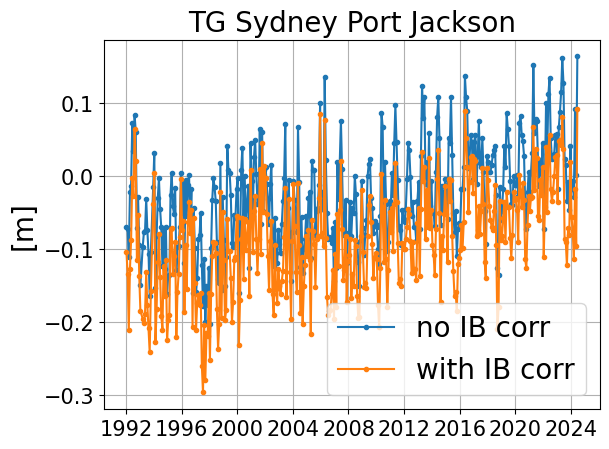

In [7]:
fig, ax = plt.subplots()
ax.plot(tg_psmsl.index, tg_psmsl['SSH_RLR[m]'], '.-', label='no IB corr')
ax.plot(tg_psmsl.index, tg_psmsl['SSH_RLR[m]']-tg_psmsl['corr_ib[m]'], '.-', label='with IB corr')
ax.set_title('TG Sydney Port Jackson')
ax.set_ylabel('[m]')
ax.legend()
ax.grid()

### OpenADB ALES

In [8]:
# Select which missions to use
missions = [
            'Envisat (Version 3)', # 21.06.2002 - 11.10.2010
            'Jason-1',             # 15.01.2002 - 14.01.2009
            # 'Jason-1 (EM)',      # 10.02.2009 - 02.03.2012
            # 'Jason-1 (GM)',      # 11.05.2012 - 17.06.2013
            'Jason-2',             # 12.07.2008 - 30.09.2016
            # 'Jason-2 (EM)',      # 15.10.2016 - 17.05.2017
            'Jason-3',             # 18.02.2016 - 20.04.2019
            'Saral',               # 17.03.2013 - 28.06.2016
            # 'Saral (DP)',        # 05.07.2016 - 14.04.2019
            'Sentinel-3A',         # 24.11.2017 - 04.04.2020
            'Sentinel-3B',         # 26.11.2018 - 12.04.2020
           ]

# Merge all .nc-files
fn = 'ales.nc'
if (not os.path.isfile(path_output + fn)):
    ales = CD_altimetry.combine_openadb_nc_files(path_input + '2_Narrabeen_OpenADB')
    ales = CD_altimetry.select_missions(ales, missions)
    # Clean according to OpenADB instructions (e.g. dist to coast, std, ...)
    ales = CD_altimetry.clean_openadb_ales(ales)
    ales.to_netcdf(path_output + fn)
else:
    ales = xr.open_dataset(path_output + fn)

TG is about 15 (12-17) km away from the study site  
But maybe still better to compare with this TG than just taking a huge polygon  

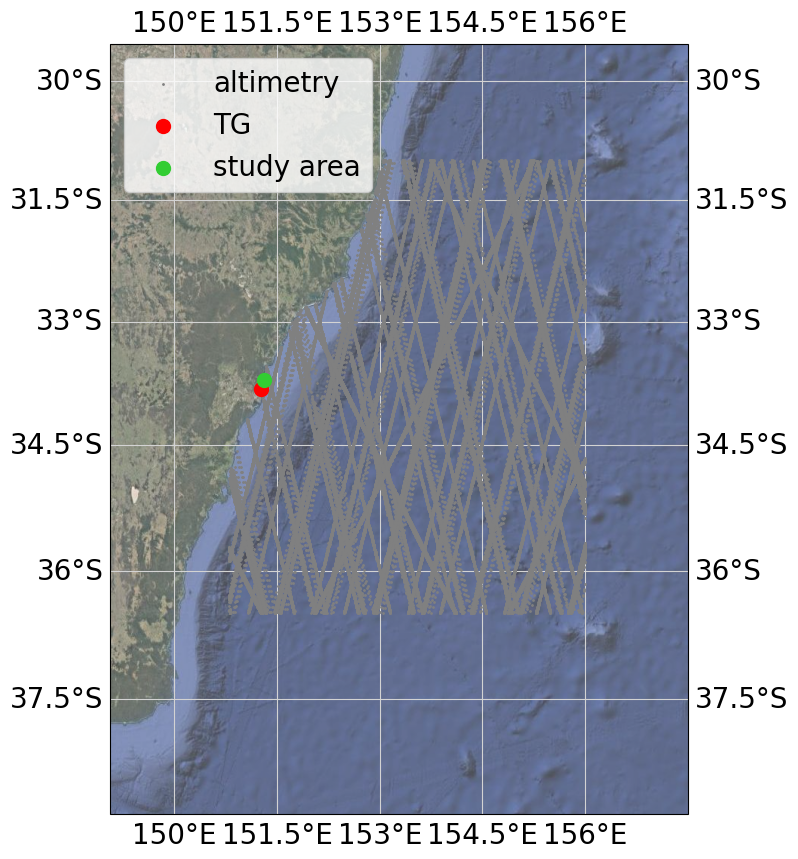

In [9]:
tg_lat = -33.8255
tg_lon = 151.2585

lon_narra_pf4 = 151.30071
lat_narra_pf4 = -33.71728

# extent = [151.29, 151.31, -33.74, -33.70]
extent = None
fig, ax = CD_visualisation.plot_basemap(extent, zoom=7)
ax.scatter(ales.glon, ales.glat, transform=ccrs.PlateCarree(), s=1, zorder=3, c='grey', label='altimetry')
ax.scatter(tg_lon, tg_lat, transform=ccrs.PlateCarree(), s=100, c='red', zorder=3, label='TG')
ax.scatter(lon_narra_pf4, lat_narra_pf4, transform=ccrs.PlateCarree(), s=100, c='limegreen', zorder=3, label='study area')
ax.legend();

extracted cells: 20 32 19 18 31 30 44 (latter 3 not because they're great but because topex has no data in the first 3 close to the coast)

In [10]:
# Make/load timeseries
fn = f'ales_ts_epgs{epsg_out}.csv'
if (not os.path.isfile(path_output+fn)):
    labels = {'time':'time', 'lon':'glon', 'lat':'glat', 'sla':None, 'ssh':'ssh', 'mssh':'mssh'}
    
    tg = tg_psmsl['SSH_RLR[m]'] - tg_psmsl['corr_ib[m]']
    
    gridsize = {'x':50, 'y':50} # [km]
    period_covered = {'min':'2003-01-01', 'max':'2020-01-01'}
    freq_average = 'ME' # period over which to average in pd.Grouper
    
    # 'ME': month end frequency
    # https://pandas.pydata.org/pandas-docs/stable/user_guide/timeseries.html#offset-aliases
    
    %matplotlib inline
    ales_ts = CD_altimetry.get_altimetry_timeseries_with_TG(ales, labels, epsg_in, epsg_out, tg, gridsize, period_covered, freq_average)
    ales_ts.to_csv(path_output+fn)
else:
    ales_ts = pd.read_csv(path_output+fn, index_col='time', parse_dates=['time'])

In [11]:
ales_ts

,sla_temp_av,ssh_temp_av,mss_temp_av
time,,,
2002-01-31 00:00:00+00:00,0.180104,22.212602,22.032497
2002-02-28 00:00:00+00:00,0.245443,22.706294,22.460852
2002-03-31 00:00:00+00:00,0.141043,22.550870,22.409827
2002-04-30 00:00:00+00:00,0.004219,22.022914,22.018695
2002-05-31 00:00:00+00:00,0.103171,22.617780,22.514609
...,...,...,...
2019-12-31 00:00:00+00:00,0.128396,21.455258,21.326862
2020-01-31 00:00:00+00:00,0.196996,21.503945,21.306949
2020-02-29 00:00:00+00:00,0.143063,21.590233,21.447170


### RADS T/P

In [12]:
path_tp = path_input + '1_marge_topexA_Narrabeen/'
tx_047 = xr.open_dataset(path_tp+'rads2nc_pass047.nc')
tx_062 = xr.open_dataset(path_tp+'rads2nc_pass062.nc')
tx_123 = xr.open_dataset(path_tp+'rads2nc_pass123.nc')
tx_138 = xr.open_dataset(path_tp+'rads2nc_pass138.nc')
tx_214 = xr.open_dataset(path_tp+'rads2nc_pass214.nc')

tx_combined = xr.merge([tx_047, tx_062, tx_123, tx_138, tx_214])
tx = CD_altimetry.clean_rads(tx_combined, 'ssha')

cells extraced (same area as for ALES extracted): 29 28 27 40, cells close to the coast have no data

In [13]:
# Make/load timeseries
fn = f'tx_ts_epsg{epsg_out}.csv'
if (not os.path.isfile(path_output+fn)):
    labels = {'time':'time', 'lon':'lon', 'lat':'lat', 'sla':'ssha', 'ssh':None, 'mssh':'mss_dtu15'}
    
    tg = tg_psmsl['SSH_RLR[m]'] - tg_psmsl['corr_ib[m]']
    
    gridsize = {'x':50, 'y':50} # [km]
    period_covered = {'min':'1993-01-31', 'max':'2002-03-31'}
    freq_average = 'ME' # period over which to average in pd.Grouper
    
    # 'ME': month end frequency
    # https://pandas.pydata.org/pandas-docs/stable/user_guide/timeseries.html#offset-aliases
    
    # %matplotlib qt5
    tx_ts = CD_altimetry.get_altimetry_timeseries_with_TG(tx, labels, epsg_in, epsg_out, tg, gridsize, period_covered, freq_average)
    tx_ts.to_csv(path_output+fn)
else:
    tx_ts = pd.read_csv(path_output+fn, index_col='time', parse_dates=['time'])

In [14]:
tx_ts

,sla_temp_av,ssh_temp_av,mss_temp_av
time,,,
1992-09-30 00:00:00+00:00,0.025352,0.0,21.449675
1992-10-31 00:00:00+00:00,0.039863,0.0,21.142303
1992-11-30 00:00:00+00:00,-0.024740,0.0,21.222372
1992-12-31 00:00:00+00:00,-0.130757,0.0,20.808262
1993-01-31 00:00:00+00:00,-0.162223,0.0,21.197658
...,...,...,...
2005-06-30 00:00:00+00:00,0.222022,0.0,20.482592
2005-07-31 00:00:00+00:00,-0.002139,0.0,20.502242
2005-08-31 00:00:00+00:00,-0.069390,0.0,20.446394


## Create time series by weighting cells according to their correlation and trend

In [21]:
cells_to_extract_ales = [20,32,19,18,31,30,44]
cells_to_extract_tx = [29,28,27,40]

alt_ex_ales = CD_altimetry.extract_single_cell(ales['ssh']-ales['mssh'], ales['glon'], ales['glat'], ales['time'], cells_to_extract_ales, epsg_in, epsg_out)
alt_ex_tx = CD_altimetry.extract_single_cell(tx['ssha'], tx['lon'], tx['lat'], tx['time'], cells_to_extract_tx, epsg_in, epsg_out)

In [23]:
tg = tg_psmsl['SSH_RLR[m]'] - tg_psmsl['corr_ib[m]']
corr_ales = CD_altimetry.get_correlation_per_cell(alt_ex_ales, tg)
corr_tx = CD_altimetry.get_correlation_per_cell(alt_ex_tx, tg)

In [24]:
trend_diff_ales = CD_altimetry.get_trend_diff_per_cell(alt_ex_ales, tg)
trend_diff_tx = CD_altimetry.get_trend_diff_per_cell(alt_ex_tx, tg)

In [25]:
ales_ts = CD_altimetry.timeseries_as_weighted_average(alt_ex_ales, corr_ales, trend_diff_ales, w_corr=.5)
tx_ts = CD_altimetry.timeseries_as_weighted_average(alt_ex_tx, corr_tx, trend_diff_tx, w_corr=.5)

### Combine Tx and ALES

In [34]:
tx_biased_to_ales = CD_altimetry.equalise_timeseries(tx_ts['sla'], ales_ts['sla'])

combined = pd.concat([tx_biased_to_ales, ales_ts['sla']])
combined = combined.dropna()

There are 46 overlapping values in the same time period.
Bias: -0.072 m


### Compare result against tide gauge

In [36]:
alt_mean = np.nanmean(combined.values)
tg_mean = np.nanmean(tg)
bias = tg_mean - alt_mean
tg_debias = tg - bias

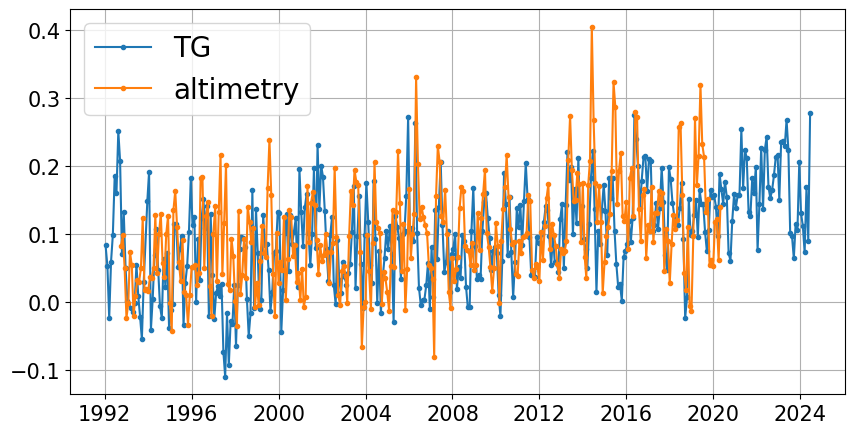

In [37]:
fig, ax = plt.subplots(figsize=(10,5))
ax.plot(tg_psmsl.index, tg_debias, '.-', label='TG')
ax.plot(combined.index, combined.values, '.-', label='altimetry')
ax.grid()
ax.legend()

In [40]:
tg_at_alt_time = CD_altimetry.interpolate_tg_to_alt(combined.index, tg_debias.index, tg_debias)

corr, p = stats.pearsonr(combined, tg_at_alt_time)
print(f'corr: {round(corr,4)}, p-value: {p}')

rmse = CD_altimetry.compute_RMSE(combined, tg_at_alt_time)
print(f'RMSE: {round(rmse,3)} m')

x = CD_helper_functions.datetime_to_decimal_numbers(tg_at_alt_time.index)
trend_tg = CD_statistics.compute_trend(x, tg_at_alt_time)
print(f'Trend from tide gauge: {trend_tg*1000} mm/year')

x = CD_helper_functions.datetime_to_decimal_numbers(combined.index)
trend_alt = CD_statistics.compute_trend(x, combined)
print(f'Trend from altimetry: {trend_alt*1000} mm/year')

corr: 0.3492, p-value: 5.940887885482844e-11
RMSE: 0.076 m
Trend from tide gauge: 3.6 mm/year
Trend from altimetry: 3.4 mm/year


In [43]:
fn = f'tp_plus_ales_epsg{epsg_out}.csv'
if (not os.path.isfile(path_output+fn)):
    combined.to_frame().rename_axis('time').to_csv(path_output+fn)